In [12]:
!pip install -q kaggle ultralytics

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.7/46.7 kB 936.1 kB/s eta 0:00:00 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 10.0 MB/s eta 0:00:0000:010:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 88.7/88.7 kB 9.7 MB/s eta 0:00:00


In [14]:
from google.colab import drive
drive.mount("/content/drive")

Mounted at /content/drive


In [8]:
!kaggle datasets download -d vivek603/vehicle-detection-sample-and-output-videos --unzip

Dataset URL: https://www.kaggle.com/datasets/vivek603/vehicle-detection-sample-and-output-videos
License(s): unknown
100% 242M/242M [00:03<00:00, 80.9MB/s] 



In [13]:
from collections import Counter, defaultdict, deque
from pathlib import Path
from time import perf_counter
import csv

import cv2
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from ultralytics import YOLO

Creating new Ultralytics Settings v0.0.8 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/usage/settings.


In [ ]:
INPUT_VIDEO = Path("/content/vehicle_detection.mp4")
OUTPUT_DIR = Path("/content/drive/MyDrive/Vision/vision_unit_03/outputs/day_06")

OUTPUT_VIDEO = OUTPUT_DIR / "traffic_analytics_final.mp4"
EVENTS_CSV = OUTPUT_DIR / "crossing_events_final.csv"

MODEL_PATH = "yolo26n.pt"
TRACKER_PATH = "bytetrack.yaml"
LINE_Y_RATIO = 0.68
MAX_CROSSING_GAP = 3

In [19]:
preview_cap = cv2.VideoCapture(str(INPUT_VIDEO))
sucess, preview = preview_cap.read()

source_fps = preview_cap.get(cv2.CAP_PROP_FPS)
preview_cap.release()

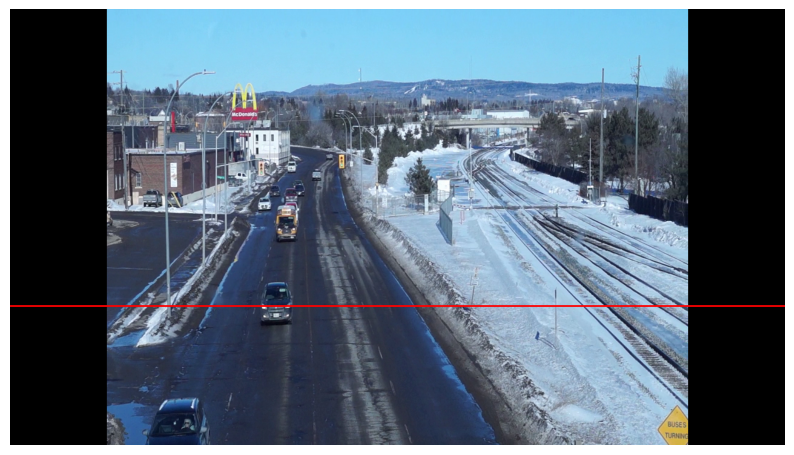

Resolution: 1280x720 | Source FPS: 30.01
Counting line: y=490


In [ ]:
height, width = preview.shape[:2]
line_y = round(height * LINE_Y_RATIO)

cv2.line(preview, (0, line_y), (width - 1, line_y), (0, 0, 255), 2)
plt.figure(figsize=(10, 6))
plt.imshow(cv2.cvtColor(preview, cv2.COLOR_BGR2RGB))
plt.axis("off")
plt.show()

print(f"Resolution: {width}x{height} | Source FPS: {source_fps:.2f}")
print(f"Counting line: y={line_y}")

**pipeline**